# 04_08 Regression - RandomForestRegressor
Train and evaluate RandomForestRegressor.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train RandomForestRegressor va visual ket qua du doan tren test set.
- Muc tieu ky thuat: Hien thi metric table + scatter actual/prediction + residual histogram.

26/03/31 22:24:57 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 192.168.2.18 instead (on interface en0)
26/03/31 22:24:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/03/31 22:24:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/03/31 22:24:57 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/31 22:24:57 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


26/03/31 22:25:10 WARN DAGScheduler: Broadcasting large task binary with size 1439.1 KiB


26/03/31 22:25:11 WARN DAGScheduler: Broadcasting large task binary with size 2032.5 KiB


...

26/03/31 22:25:18 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB


26/03/31 22:25:19 WARN DAGScheduler: Broadcasting large task binary with size 6.3 MiB


26/03/31 22:25:21 WARN DAGScheduler: Broadcasting large task binary with size 7.4 MiB


{'model_family': 'regression', 'model_name': 'RandomForestRegressor', 'val_rmse': 202.05173445155165, 'val_mae': 94.47929958997244, 'val_r2': 0.1346451571725208, 'rmse': 220.67739154598829, 'mae': 94.52213847044845, 'r2': 0.12247451585922786, 'test_rmse': 220.67739154598829, 'test_mae': 94.52213847044845, 'test_r2': 0.12247451585922786, 'train_rows': 69077, 'val_rows': 14728, 'test_rows': 14861}


,model_family,model_name,val_rmse,val_mae,val_r2,rmse,mae,r2,test_rmse,test_mae,test_r2,train_rows,val_rows,test_rows
0,regression,RandomForestRegressor,202.051734,94.4793,0.134645,220.677392,94.522138,0.122475,220.677392,94.522138,0.122475,69077,14728,14861


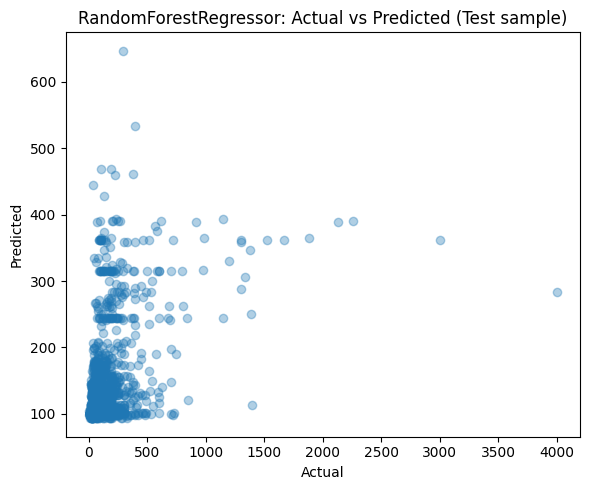

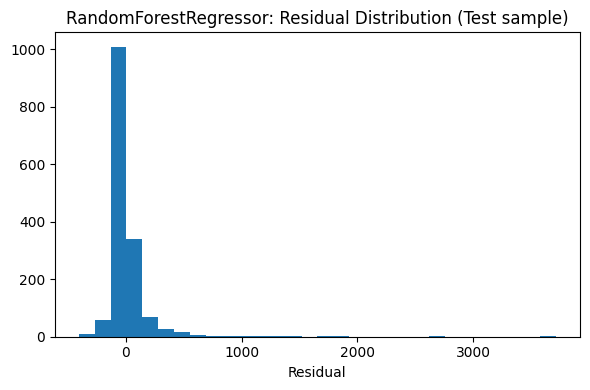

26/03/31 22:25:25 WARN TaskSetManager: Stage 55 contains a task of very large size (2365 KiB). The maximum recommended task size is 1000 KiB.


428

In [1]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
spark=(SparkSession.builder.appName('04_08_rf_reg').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=='notebooks' else Path.cwd().resolve()
FEATURE_DIR=PROJECT_ROOT/'data'/'processed'/'features'
MODEL_DIR=PROJECT_ROOT/'models'/'regression'/'random_forest'
METRIC_DIR=PROJECT_ROOT/'reports'/'model_metrics'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
train_df=spark.read.parquet(str(FEATURE_DIR/'regression_train')).select('order_id','label','features').dropna()
val_df=spark.read.parquet(str(FEATURE_DIR/'regression_val')).select('order_id','label','features').dropna()
test_df=spark.read.parquet(str(FEATURE_DIR/'regression_test')).select('order_id','label','features').dropna()
rf=RandomForestRegressor(featuresCol='features',labelCol='label',numTrees=160,maxDepth=14,seed=42)
m=rf.fit(train_df)
pred_val=m.transform(val_df)
pred_test=m.transform(test_df)
val_rmse=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='rmse').evaluate(pred_val)
val_mae=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='mae').evaluate(pred_val)
val_r2=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='r2').evaluate(pred_val)
test_rmse=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='rmse').evaluate(pred_test)
test_mae=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='mae').evaluate(pred_test)
test_r2=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='r2').evaluate(pred_test)
metrics={'model_family':'regression','model_name':'RandomForestRegressor','val_rmse':float(val_rmse),'val_mae':float(val_mae),'val_r2':float(val_r2),'rmse':float(test_rmse),'mae':float(test_mae),'r2':float(test_r2),'test_rmse':float(test_rmse),'test_mae':float(test_mae),'test_r2':float(test_r2),'train_rows':train_df.count(),'val_rows':val_df.count(),'test_rows':test_df.count()}
print(metrics)
display(pd.DataFrame([metrics]))
sample_pdf=pred_test.select('label','prediction').sample(False,0.1,42).toPandas()
if not sample_pdf.empty:
    sample_pdf['residual']=sample_pdf['label']-sample_pdf['prediction']
    plt.figure(figsize=(6,5))
    plt.scatter(sample_pdf['label'], sample_pdf['prediction'], alpha=0.35)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('RandomForestRegressor: Actual vs Predicted (Test sample)')
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(6,4))
    plt.hist(sample_pdf['residual'], bins=30)
    plt.title('RandomForestRegressor: Residual Distribution (Test sample)')
    plt.xlabel('Residual')
    plt.tight_layout()
    plt.show()
m.write().overwrite().save(str(MODEL_DIR))
(METRIC_DIR/'regression_random_forest.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')